In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# This will search and print the exact path of your file
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Superstore' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Sqrock_Internship /Project1_Sales/Sample - Superstore.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Sqrock_Internship /Project1_Sales/Sample - Superstore.csv', encoding='latin1')
print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [8]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())


(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Day'] = df['Order Date'].dt.day
print(df[['Order Date','Month','Year','Day']].head())

  Order Date  Month  Year  Day
0 2016-11-08     11  2016    8
1 2016-11-08     11  2016    8
2 2016-06-12      6  2016   12
3 2015-10-11     10  2015   11
4 2015-10-11     10  2015   11


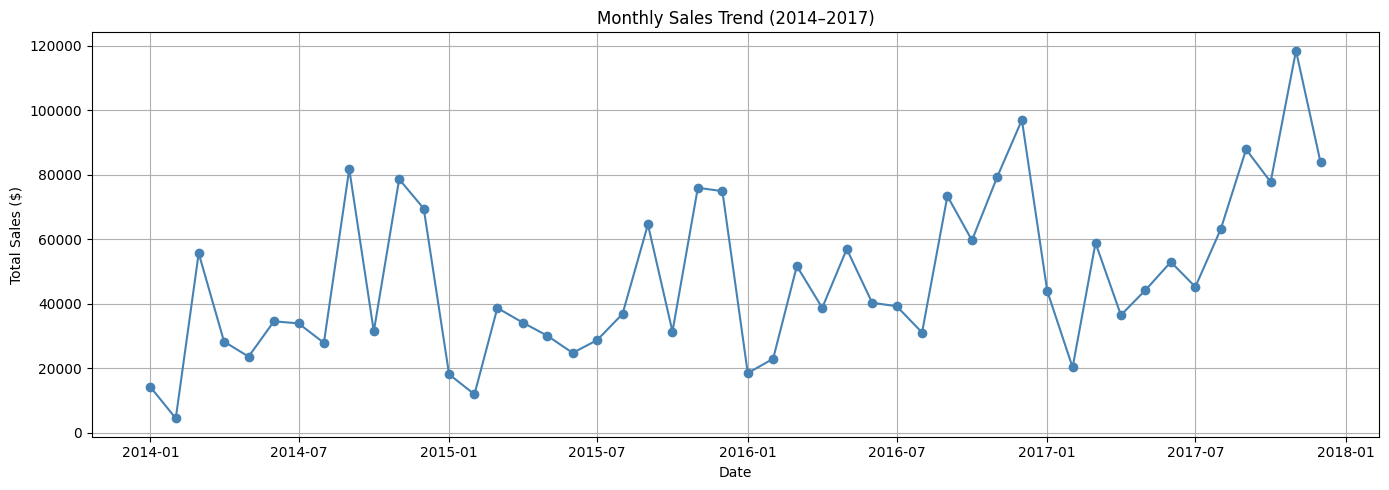

In [10]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(Day=1))

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', color='steelblue')
plt.title('Monthly Sales Trend (2014–2017)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

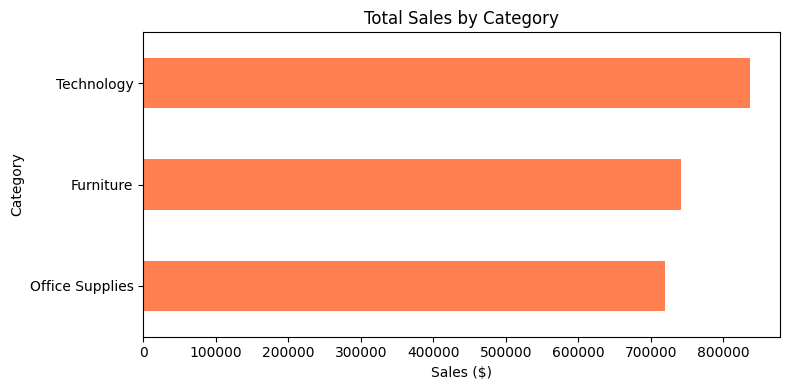

In [11]:
plt.figure(figsize=(8,4))
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', color='coral')
plt.title('Total Sales by Category')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[['Month', 'Year', 'Day']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [13]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"MAE  (Mean Absolute Error) : ${mae:.2f}")
print(f"RMSE (Root Mean Sq Error)  : ${rmse:.2f}")

MAE  (Mean Absolute Error) : $312.17
RMSE (Root Mean Sq Error)  : $803.54


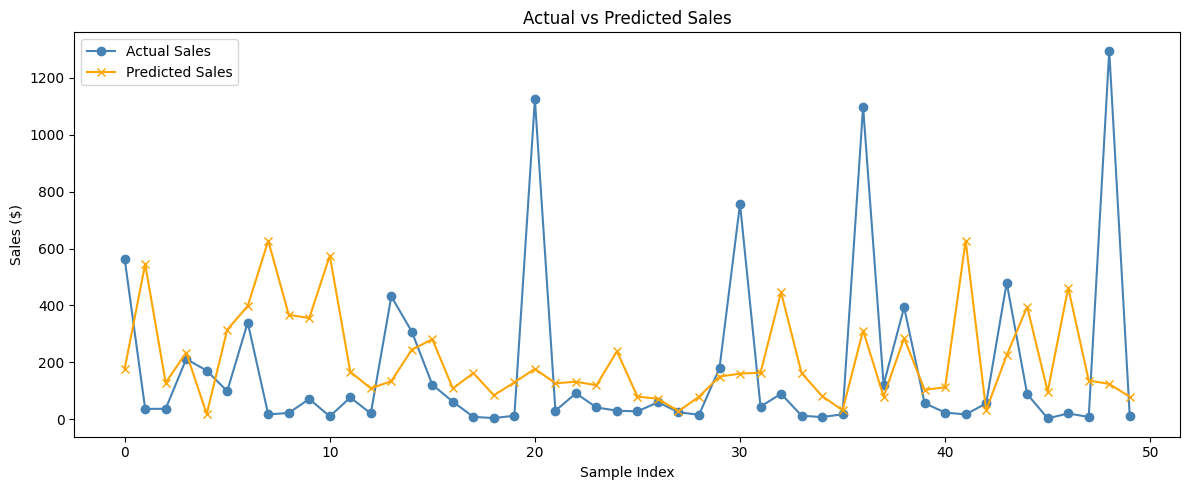

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:50], label='Actual Sales', color='steelblue', marker='o')
plt.plot(preds[:50], label='Predicted Sales', color='orange', marker='x')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Sample Index')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()